# Task-1

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import csv

In [92]:
rows = []

with open("student_performance.csv") as f:
    for r in csv.DictReader(f):

        # Drop rows with missing values
        if r["sleep_hours"] == "" or r["prev_score"] == "":
            continue

        # Remove impossible study-hours outlier
        if float(r["study_hours"]) > 12:
            continue

        rows.append(r)

# Create NumPy arrays
study = np.array([float(r["study_hours"]) for r in rows])
final = np.array([float(r["final_score"]) for r in rows])
attendance = np.array([float(r["attendance_pct"]) for r in rows])
sleep = np.array([float(r["sleep_hours"]) for r in rows])
passed = np.array([int(r["passed"]) for r in rows])

print("Number of students:", len(rows))

Number of students: 492


In [93]:
# Mean
final_mean = np.mean(final)

# Median
final_median = np.median(final)

# Mode
final_mode = stats.mode(final, keepdims=True).mode[0]

# Standard deviation
final_std = np.std(final, ddof=1)

# Variance
final_variance = np.var(final, ddof=1)

# Percentiles
final_p25, final_p50, final_p75 = np.percentile(final, [25, 50, 75])

print("FINAL SCORE STATISTICS:")
print("Mean:", round(final_mean, 2))
print("Median:", round(final_median, 2))
print("Mode:", round(final_mode, 2))
print("Standard deviation:", round(final_std, 2))
print("Variance:", round(final_variance, 2))
print("25th percentile:", round(final_p25, 2))
print("50th percentile:", round(final_p50, 2))
print("75th percentile:", round(final_p75, 2))

FINAL SCORE STATISTICS:
Mean: 62.88
Median: 63.8
Mode: 67.1
Standard deviation: 12.57
Variance: 158.0
25th percentile: 54.0
50th percentile: 63.8
75th percentile: 70.95


In [94]:
# Mean
study_mean = np.mean(study)

# Median
study_median = np.median(study)

# Mode
study_mode = stats.mode(study, keepdims=True).mode[0]

# Standard deviation
study_std = np.std(study, ddof=1)

# Variance
study_variance = np.var(study, ddof=1)

# Percentiles
study_p25, study_p50, study_p75 = np.percentile(study, [25, 50, 75])

print("STUDY HOURS STATISTICS:")
print("Mean:", round(study_mean, 2))
print("Median:", round(study_median, 2))
print("Mode:", round(study_mode, 2))
print("Standard deviation:", round(study_std, 2))
print("Variance:", round(study_variance, 2))
print("25th percentile:", round(study_p25, 2))
print("50th percentile:", round(study_p50, 2))
print("75th percentile:", round(study_p75, 2))

STUDY HOURS STATISTICS:
Mean: 4.99
Median: 5.02
Mode: 4.06
Standard deviation: 1.93
Variance: 3.72
25th percentile: 3.69
50th percentile: 5.02
75th percentile: 6.22


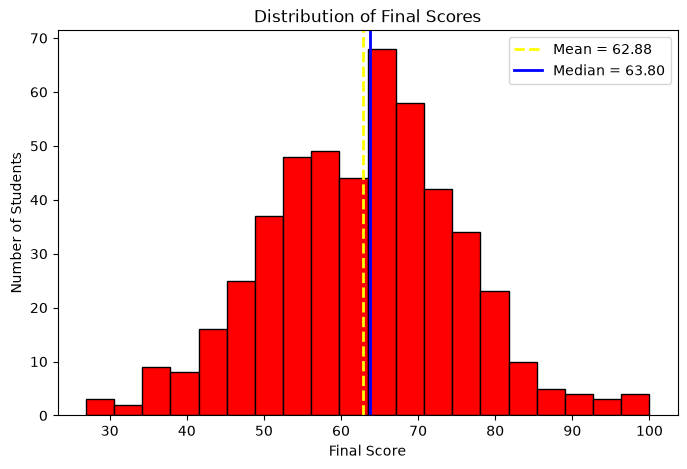

In [120]:
plt.figure(figsize=(8, 5))

plt.hist(final, bins=20, edgecolor="black", color="red")

plt.axvline(final_mean, linestyle="--", linewidth=2, label=f"Mean = {final_mean:.2f}" , color="yellow")
plt.axvline(final_median, linestyle="-", linewidth=2, label=f"Median = {final_median:.2f}",color="blue")

plt.xlabel("Final Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Scores")

plt.legend()
plt.show()

In [96]:
difference = abs(final_mean - final_median)

print("Mean:", round(final_mean, 2))
print("Median:", round(final_median, 2))
print("Difference:", round(difference, 2))

if difference < 2:
    print("The mean and median are close.")
    print("This suggests the distribution is fairly symmetric.")
else:
    print("The mean and median are far apart.")
    print("This suggests the distribution may be skewed.")

Mean: 62.88
Median: 63.8
Difference: 0.92
The mean and median are close.
This suggests the distribution is fairly symmetric.


In [97]:
#The final scores of the 492 students have a mean of about 62.88 and a median of 63.80.
#Since the mean and median are close, the final-score distribution appears fairly symmetric and does not show strong skew.
#The standard deviation is about 12.57, which shows that students' scores have a noticeable amount of variation around the average. 
#The middle 50% of students scored between about 54 and 71. Overall, the final scores are centered around the low 60s with moderate spread.

# Task-2

In [98]:
# Sample statistics
n = len(final)
mean = final.mean()
std = final.std(ddof=1)

# Standard error
standard_error = std / np.sqrt(n)

# 95% confidence interval
ci_low, ci_high = stats.t.interval(
    0.95,
    df=n - 1,
    loc=mean,
    scale=standard_error
)

print("95% Confidence Interval")
print(f"Sample size       = {n}")
print(f"Sample mean       = {mean:.2f}")
print(f"Standard deviation = {std:.2f}")
print(f"Standard error    = {standard_error:.3f}")
print(f"95% CI            = ({ci_low:.2f}, {ci_high:.2f})")

95% Confidence Interval
Sample size       = 492
Sample mean       = 62.88
Standard deviation = 12.57
Standard error    = 0.567
95% CI            = (61.77, 63.99)


In [99]:
### Interpretation
#The sample mean final score is about 62.88.
#The 95% confidence interval is approximately 61.77 to 63.99.
#This means that, based on this sample, the true average final score is estimated to be within this range with 95% confidence.
#The confidence interval gives us a range instead of relying only on one sample mean.

In [100]:
print("How sample size affects the 95% confidence interval:")

for sample_n in [30, 100, 200, 492, 1000, 2000]:

    se = final.std(ddof=1) / np.sqrt(sample_n)

    lo, hi = stats.t.interval(
        0.95,
        df=sample_n - 1,
        loc=final.mean(),
        scale=se
    )

    print(
        f"n = {sample_n:4}  "
        f"CI = ({lo:.2f}, {hi:.2f})  "
        f"Width = {hi - lo:.2f}"
    )

How sample size affects the 95% confidence interval:
n =   30  CI = (58.18, 67.57)  Width = 9.39
n =  100  CI = (60.38, 65.37)  Width = 4.99
n =  200  CI = (61.13, 64.63)  Width = 3.51
n =  492  CI = (61.77, 63.99)  Width = 2.23
n = 1000  CI = (62.10, 63.66)  Width = 1.56
n = 2000  CI = (62.33, 63.43)  Width = 1.10


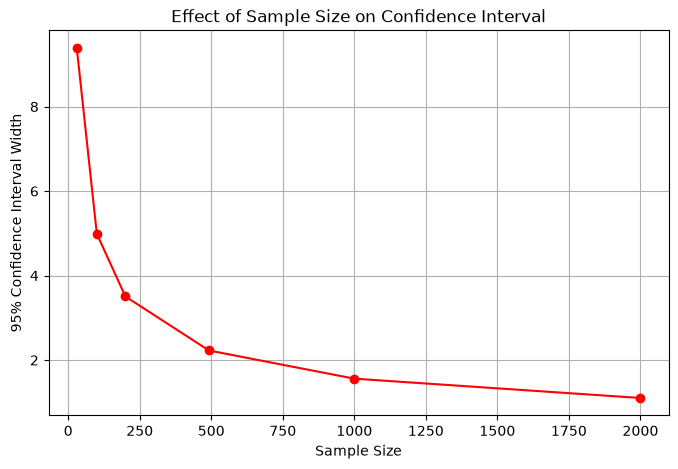

In [121]:
sample_sizes = [30, 100, 200, 492, 1000, 2000]
ci_widths = []

for sample_n in sample_sizes:

    se = final.std(ddof=1) / np.sqrt(sample_n)

    lo, hi = stats.t.interval(
        0.95,
        df=sample_n - 1,
        loc=final.mean(),
        scale=se
    )

    ci_widths.append(hi - lo)

plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, ci_widths, marker="o",color="red")

plt.xlabel("Sample Size")
plt.ylabel("95% Confidence Interval Width")
plt.title("Effect of Sample Size on Confidence Interval")
plt.grid(True)

plt.show()

In [102]:
#The 95% confidence interval for the average final score is approximately 61.77 to 63.99.
#As the sample size increases, the confidence interval becomes narrower. This happens because the standard error decreases as the sample size increases.
#Therefore, larger samples give us a more precise estimate of the population average.

# Task-3

In [103]:
# Students who sleep 7 hours or more
high_sleep = final[sleep >= 7]

# Students who sleep less than 7 hours
low_sleep = final[sleep < 7]

print(f"Well-rested (>=7h): n = {len(high_sleep)}")
print(f"Less sleep (<7h):   n = {len(low_sleep)}")

print(f"\nWell-rested mean score = {high_sleep.mean():.2f}")
print(f"Less sleep mean score   = {low_sleep.mean():.2f}")

difference = high_sleep.mean() - low_sleep.mean()

print(f"\nDifference in means = {difference:.2f} points")

Well-rested (>=7h): n = 250
Less sleep (<7h):   n = 242

Well-rested mean score = 64.14
Less sleep mean score   = 61.57

Difference in means = 2.57 points


In [104]:
#Hypotheses:-
#Null Hypothesis (H₀):There is no difference in the average final scores between students who sleep 7 hours or more and students who sleep less than 7 hours.

#Alternative Hypothesis (H₁):There is a difference in the average final scores between the two groups.
#We use a significance level of α = 0.05.

In [105]:
# Independent two-sample t-test
t_stat, p_value = stats.ttest_ind(
    high_sleep,
    low_sleep,
    equal_var=False
)

print("Independent t-test")
print(f"t-statistic = {t_stat:.3f}")
print(f"p-value     = {p_value:.6f}")

Independent t-test
t-statistic = 2.277
p-value     = 0.023189


In [106]:
alpha = 0.05

print(f"Significance level = {alpha}")

if p_value < alpha:
    print("Decision: Reject the null hypothesis.")
    print("Result: Statistically significant.")
else:
    print("Decision: Fail to reject the null hypothesis.")
    print("Result: Not statistically significant.")

Significance level = 0.05
Decision: Reject the null hypothesis.
Result: Statistically significant.


In [107]:
print(f"Mean difference = {difference:.2f} points")

Mean difference = 2.57 points


In [108]:
#The difference between the two group means is about 2.57 points.
#Statistical significance tells us whether the observed difference is unlikely to be due to chance under the null hypothesis.
#Practical importance asks whether a difference of about 2.57 points is large enough to matter in a real educational setting.
#Therefore, statistical significance and practical importance should be considered separately.

In [109]:
#Students who slept 7 hours or more had an average final score of about 64.14, while students who slept less than 7 hours had an average score of about 61.57.
#The difference between the group means was approximately 2.57 points.
#The independent t-test was used to determine whether this difference could reasonably be explained by random variation.
#Based on the p-value and the 0.05 significance level, we make the appropriate decision about the null hypothesis.
#The size of the difference should also be considered separately from statistical significance because a statistically significant result is not necessarily practically important.

# Task-4

In [110]:
# Students who studied a lot
studied_a_lot = study >= 5

# Create 2x2 table
table = np.array([
    [
        np.sum(studied_a_lot & (passed == 1)),
        np.sum(studied_a_lot & (passed == 0))
    ],
    [
        np.sum(~studied_a_lot & (passed == 1)),
        np.sum(~studied_a_lot & (passed == 0))
    ]
])

print(table)

[[199  50]
 [ 94 149]]


In [111]:
#Hypotheses
#Null Hypothesis (H₀):Passing and studying a lot are independent.
#Alternative Hypothesis (H₁):Passing and studying a lot are related.
#Significance level: α = 0.05

In [112]:
chi2, p_value, dof, expected = stats.chi2_contingency(table)

print(f"Chi-square statistic = {chi2:.2f}")
print(f"p-value = {p_value:.6f}")
print(f"Degrees of freedom = {dof}")

Chi-square statistic = 85.12
p-value = 0.000000
Degrees of freedom = 1


In [113]:
alpha = 0.05

if p_value < alpha:
    print("Decision: Reject the null hypothesis.")
else:
    print("Decision: Fail to reject the null hypothesis.")

Decision: Reject the null hypothesis.


In [114]:
#The p-value is less than 0.05, so we reject the null hypothesis.
#This means that passing and studying a lot are not independent in this dataset. 
#The data shows a relationship between whether a student studied a lot and whether the student passed.

In [115]:
## Type-I Error Simulation
#A Type-I error is a false positive: rejecting the null hypothesis when it is actually true.
#With α = 0.05, we accept about a 5% chance of getting a statistically significant result by chance.

# Task-5

In [116]:
rng = np.random.default_rng(0)

false_positives = 0
trials = 1000

for _ in range(trials):
    # Two groups that are truly identical
    group1 = rng.normal(50, 10, 30)
    group2 = rng.normal(50, 10, 30)

    t_stat, p_value = stats.ttest_ind(group1, group2)

    if p_value < 0.05:
        false_positives += 1

print(f"Tested two identical groups {trials} times")
print(f"Significant results: {false_positives}")
print(f"Type-I error rate: {false_positives / trials:.1%}")

Tested two identical groups 1000 times
Significant results: 56
Type-I error rate: 5.6%


In [117]:
#The two groups were created from the same distribution, so there was no real difference between them.
#However, some tests still produced p < 0.05.
#This shows that statistical tests can sometimes give a false positive.
#This is called a Type-I error.
#With α = 0.05, we expect roughly 5% false positives when the null hypothesis is actually true.

In [118]:
#Statistical Significance vs Practical Importance
#A result can be statistically significant without being practically important.
#Statistical significance tells us whether the observed result is unlikely to be due to random chance under the null hypothesis.
#Practical importance asks whether the size of the difference is meaningful in the real world.
#Therefore, we should look at both the p-value and the actual size of the difference.

In [119]:
#A p-value helps us decide whether a result is statistically significant, but it does not tell us whether the effect is practically important.
#Therefore, statistical analysis should consider both statistical significance and the actual size and meaning of the effect.